[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [1]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

Cloning into 'Thesis'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 472 (delta 92), reused 29 (delta 29), pack-reused 341 (from 2)
Receiving objects: 100% (472/472), 21.04 MiB | 15.28 MiB/s, done.
Resolving deltas: 100% (239/239), done.


In [2]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, f1_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px

import numpy as np
import pickle as pk
import copy
from collections import Counter, defaultdict
import pandas as pd

rng = np.random.default_rng(42)
rng_torch = torch.Generator().manual_seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Dataset

In [4]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
catalog.head()

Loaded 11209 events


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


In [5]:
# 90000 Registrations Pre Eruption
with open("/content/drive/MyDrive/Datasets/Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)
PRE_set = {E for St, E, Reg in pre}

with open("/content/drive/MyDrive/Datasets/Feb_Apr_Events.pkl", "rb") as f:
    Feb_Apr = pk.load(f)
FA_set = {E for St, E, Reg in pre}

# 4649 Registrations Post Eruption
with open("/content/drive/MyDrive/Datasets/Post_Events.pkl", "rb") as f:
    post = pk.load(f)
POST_set = {E for St, E, Reg in post}

In [6]:
# Per Esempio fisso mettere la variabile a True, altrimenti False
FIXED = False

per_evento = defaultdict(list)
for St, E, Reg in pre:
    per_evento[E].append((St, E, Reg))

eventi = list(per_evento.keys())

rng.shuffle(eventi)


Data = []
eventi_usati = []

for i , E in enumerate(eventi):
    if len(Data) >= 4640 * 2:
        break
    Data.extend(per_evento[E])
    eventi_usati.append(E)

Events = Data + post

Events = [(St, E, D) for (St, E, D) in Events if len(D) == 3 and all(tr.stats.npts >= 1000 for tr in D)]

print(f"Registrazioni Totali: {len(Events)}\nDati Pre Eruzione: {len(Data)}\nDati Post Eruzione {len(post)}")

Registrazioni Totali: 13937
Dati Pre Eruzione: 9288
Dati Post Eruzione 4649


In [7]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])

groups_ev = np.array([E for (St, E, D) in Events])

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

In [8]:
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[val_idx])
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[test_idx])
assert set(groups_ev[val_idx]).isdisjoint(groups_ev[test_idx])

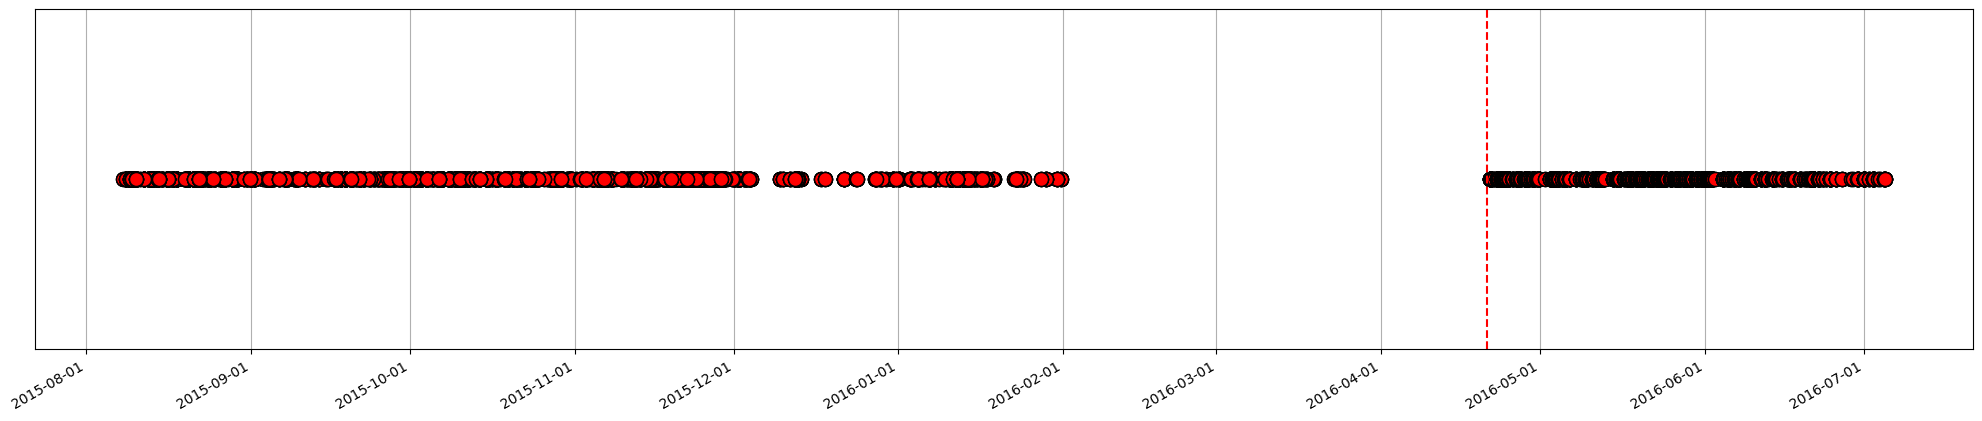

In [9]:
tempi = catalog.loc[groups_ev, "time"]

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi, [0]*len(tempi), "o",color = "red", ms = 10, markeredgecolor="black", markeredgewidth=1)
ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
ax.grid("on")
fig.autofmt_xdate()
# fig.savefig(f"{Using}: temporal.png", dpi=150, bbox_inches="tight")
plt.show()

train: Eventi Post = 3758, Eventi Pre = 7360, Proporzione eventi post = 0.338
val: Eventi Post = 449, Eventi Pre = 997, Proporzione eventi post = 0.311
test: Eventi Post = 442, Eventi Pre = 931, Proporzione eventi post = 0.322


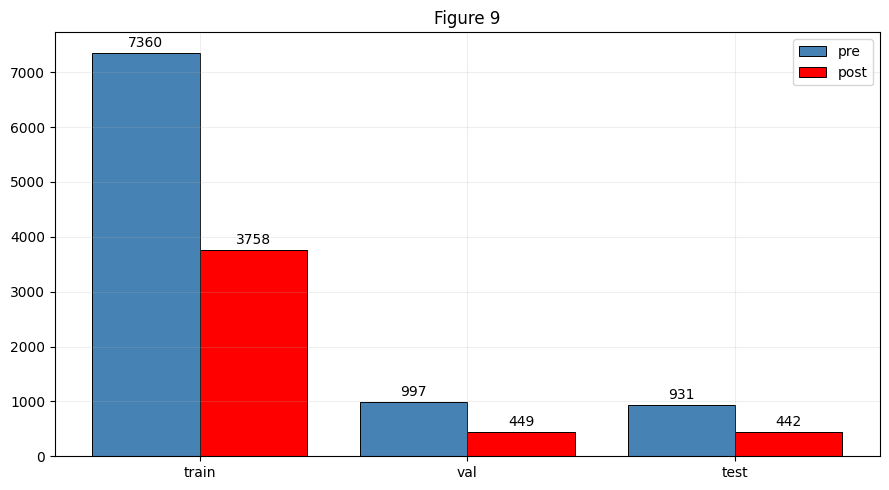

In [10]:
fig2, ax = plt.subplots(figsize=(9, 5))
w = 0.4

for i, (nome, idx) in enumerate([("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    lab = y[idx]
    n_post = int(lab.sum())
    n_pre  = int(len(lab) - lab.sum())
    print(f"{nome}: Eventi Post = {n_post}, Eventi Pre = {n_pre}, Proporzione eventi post = {lab.mean():.3f}")

    b1 = ax.bar(i - w/2, n_pre,  w, color="steelblue", label="pre"  if i == 0 else None, edgecolor="black", linewidth=0.7)
    b2 = ax.bar(i + w/2, n_post, w, color="red",       label="post" if i == 0 else None, edgecolor="black", linewidth=0.7)
    ax.bar_label(b1, padding=2)
    ax.bar_label(b2, padding=2)

ax.set_xticks(range(3))
ax.set_xticklabels(["train", "val", "test"])
ax.set_title("Figure 9")
ax.legend()
ax.grid("on", alpha = 0.2)

fig2.tight_layout()
# fig2.savefig("Figure 9 (Train/Val/Test Splits).png", dpi=150)
plt.show()

# CNN1D

In [11]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [12]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])


train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True, generator = rng_torch) # Togliere Generator per randomness
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [13]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),


            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
OneD_model = CNN().to(device)

class_weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [15]:
history1D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}
best_val_bacc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation

    OneD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)
    history1D["val_bacc"].append(val_bacc)
    history1D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [01:28<04:24,  3.53s/it]


Epoch 25
train_acc=0.8394 | val_acc=0.831 | val_bacc=0.828 | val_f1p=0.751


Training:  50%|█████     | 50/100 [02:52<02:56,  3.53s/it]


Epoch 50
train_acc=0.8884 | val_acc=0.857 | val_bacc=0.828 | val_f1p=0.765


Training:  75%|███████▌  | 75/100 [04:24<01:29,  3.57s/it]


Epoch 75
train_acc=0.9215 | val_acc=0.859 | val_bacc=0.848 | val_f1p=0.783


Training: 100%|██████████| 100/100 [05:49<00:00,  3.50s/it]


Epoch 100
train_acc=0.9324 | val_acc=0.871 | val_bacc=0.858 | val_f1p=0.798
Best val balanced accuracy: 0.8624


# CNN2D

In [16]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [17]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [18]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout2d(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [20]:
history2D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

best_val_bacc = 0.0
best_state = None

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)
    history2D["val_bacc"].append(val_bacc)
    history2D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
        tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [08:45<26:11, 20.95s/it]


Epoch 25
train_acc=0.9323 | val_acc=0.880 | val_bacc=0.907 | val_f1p=0.835


Training:  50%|█████     | 50/100 [17:28<17:24, 20.89s/it]


Epoch 50
train_acc=0.9899 | val_acc=0.929 | val_bacc=0.934 | val_f1p=0.893


Training:  75%|███████▌  | 75/100 [26:10<08:42, 20.92s/it]


Epoch 75
train_acc=0.9983 | val_acc=0.920 | val_bacc=0.930 | val_f1p=0.881


Training: 100%|██████████| 100/100 [34:59<00:00, 20.99s/it]


Epoch 100
train_acc=0.9987 | val_acc=0.928 | val_bacc=0.933 | val_f1p=0.891

Best val balanced accuracy: 0.9342


# Results Plots

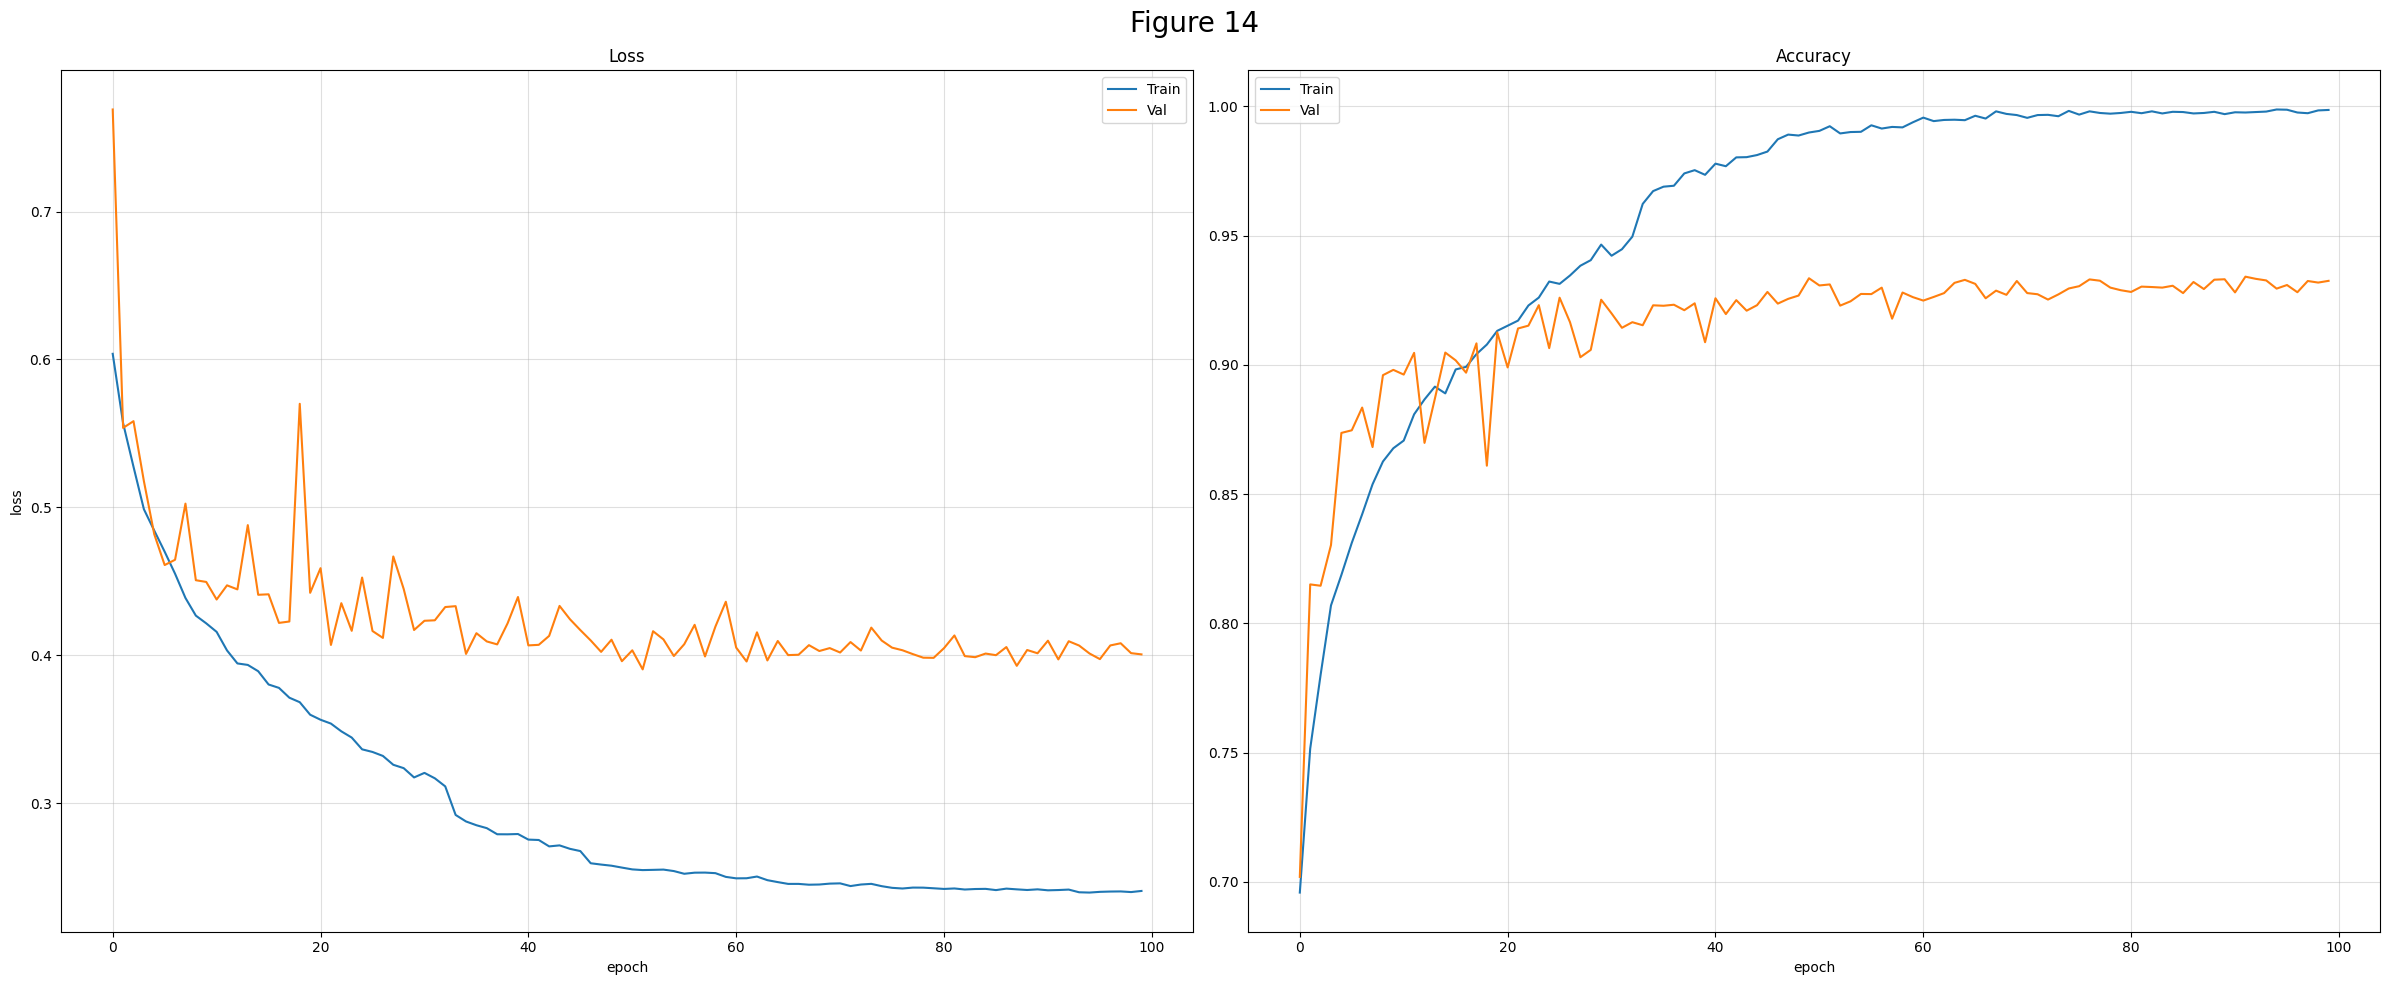

In [72]:
# history, Using, model = history1D, "CNN1D", OneD_model

history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(1, 2, figsize=(24, 10))

ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"],   label="Val")
ax[0].set_title("Loss")
ax[0].legend()
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].grid(alpha = 0.4)

ax[1].plot(history["train_acc"], label="Train")
ax[1].plot(history["val_bacc"], label="Val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].grid(alpha = 0.4)
ax[1].legend()

fig.suptitle("Figure 14", fontsize=20)
fig.tight_layout()
fig.savefig(f"Figure 14 (2DCNN Loss and Accuracy over epochs).png", dpi=150, bbox_inches="tight")
plt.show()

In [73]:
def get_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

In [74]:
model.eval()

tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)

print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      0.964     0.944     0.954       931
        post      0.887     0.925     0.906       442

    accuracy                          0.938      1373
   macro avg      0.926     0.935     0.930      1373
weighted avg      0.939     0.938     0.938      1373



In [75]:
rep = classification_report(yt, yp, target_names=["pre", "post"],
                            digits=3, output_dict=True)

df_rep = pd.DataFrame(rep).transpose().round(3)
df_rep = df_rep.drop(index=["accuracy", "macro avg"])

bacc = balanced_accuracy_score(yt, yp)
print(f"Balanced Accuracy: {bacc:.3f}")

md = df_rep.to_markdown()
print(md)

Balanced Accuracy: 0.935
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| pre          |       0.964 |    0.944 |      0.954 |       931 |
| post         |       0.887 |    0.925 |      0.906 |       442 |
| weighted avg |       0.939 |    0.938 |      0.938 |      1373 |


In [76]:
with open("2DCNN_report.md", "w") as f:
    f.write(df_rep.to_markdown())
    f.write(f"\n\n**Balanced accuracy:** {bacc:.3f}\n")

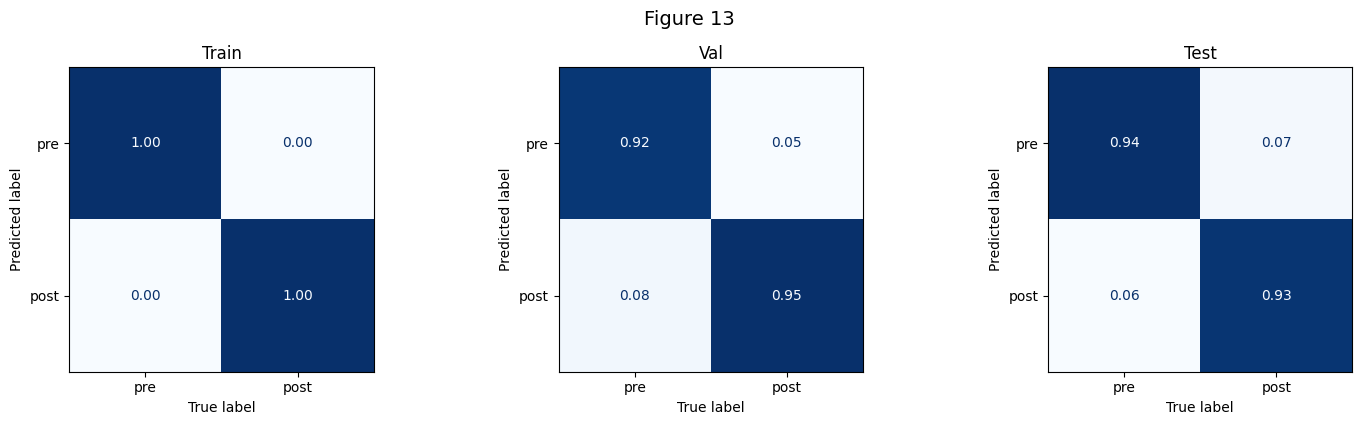

In [77]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1], normalize = "true")
    ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False, cmap = "Blues", values_format=".2f")
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(name)

fig.tight_layout()
fig.suptitle("Figure 13", fontsize=14, y=1.05)
fig.savefig(f"Figure 13 (2DCNN Confusion Matrices).png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
mis_idx = np.where(yt != yp)[0]
test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events
eventi_test = [test_events[i][1] for i in range(len(test_events))]


tot_per_evento = Counter(eventi_test)
err_per_evento = Counter(test_events[i][1] for i in mis_idx)
Pre_Post_Row = ["post" if e in POST_set else "pre" for e in list(tot_per_evento.keys())]

df_err = pd.DataFrame({
    "evento": list(tot_per_evento.keys()),
    "Pre o Post" : Pre_Post_Row,
    "Registrazioni Totali": [tot_per_evento[e] for e in tot_per_evento],
    "Registrazioni Errate": [err_per_evento.get(e, 0) for e in tot_per_evento]})

df_err["Percentuale Errata"] = (df_err["Registrazioni Errate"] / df_err["Registrazioni Totali"] * 100).round(2)

df_err = df_err[df_err["Registrazioni Errate"] > 0].reset_index(drop=True)
df_err = df_err.sort_values(["Percentuale Errata"], ascending = False).reset_index(drop=True)
df_err.to_csv("Table 2 (2DCNN wrong classifications).csv")
df_err


,evento,Pre o Post,Registrazioni Totali,Registrazioni Errate,Percentuale Errata
0,Event 7305,pre,14,12,85.71
1,Event 10833,post,5,2,40.00
2,Event 10961,post,5,2,40.00
3,Event 10962,post,5,2,40.00
4,Event 7079,pre,13,5,38.46
5,Event 925,pre,3,1,33.33
6,Event 6659,pre,12,4,33.33
7,Event 10938,post,6,2,33.33
8,Event 11061,post,12,4,33.33
9,Event 11201,post,10,3,30.00


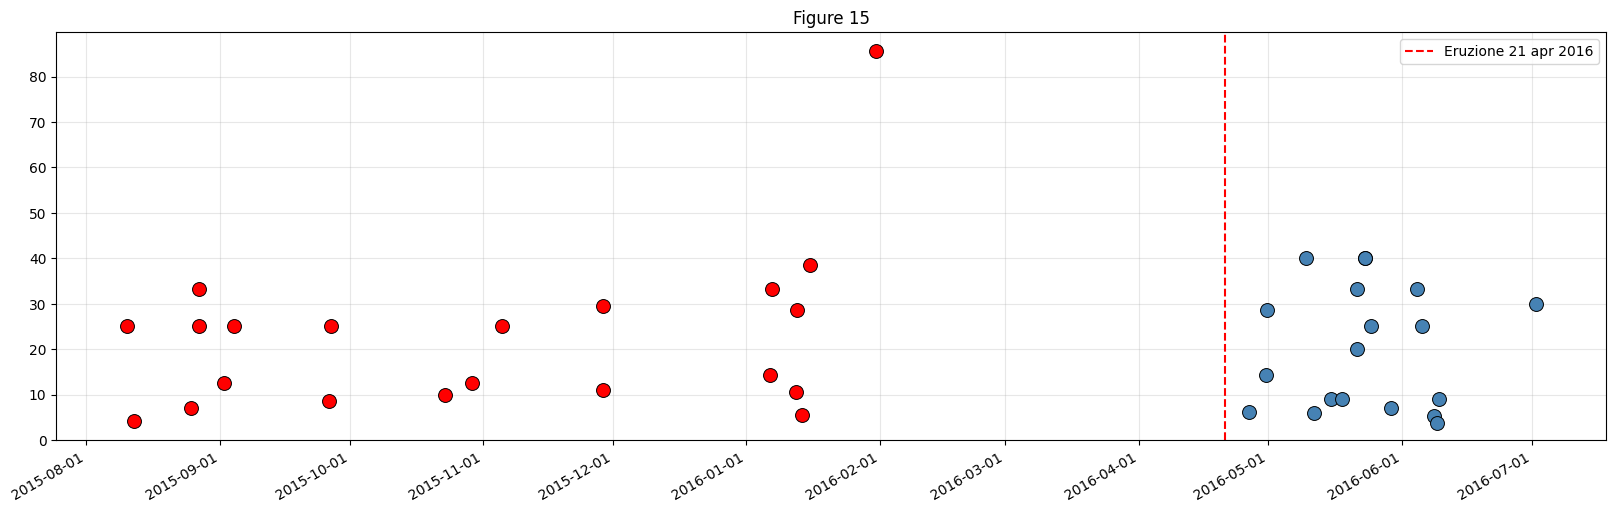

In [79]:
df_err["classe"] = df_err["evento"].apply(lambda e: 1 if e in POST_set else 0)
df_err["time"]   = df_err["evento"].map(catalog["time"])

# separo i due tipi di errore
pre_err  = df_err[df_err["classe"] == 0]   # Falsi Positivi  (pre invece di post)
post_err = df_err[df_err["classe"] == 1]   # Falsi Negativi  (post invece di pre)

fig, ax = plt.subplots(figsize=(20, 6))

# stem: l'altezza = percentuale di errore dell'evento

ax.plot(pre_err["time"], pre_err["Percentuale Errata"], "o",
        color="red", ms=10, markeredgecolor="black", markeredgewidth=0.7)

ax.plot(post_err["time"], post_err["Percentuale Errata"], "o",
        color="steelblue", ms=10, markeredgecolor="black", markeredgewidth=0.7)

ax.axvline(pd.Timestamp("2016-04-21", tz="UTC"), color="red", linestyle="--",
           linewidth=1.5, label="Eruzione 21 apr 2016")


ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.grid(alpha=0.3)
ax.legend()
ax.set_title(f"Figure 15")
fig.autofmt_xdate()
fig.savefig(f"Figure 15 (2DCNN Confidence for wrong classifications)", dpi=150, bbox_inches="tight")
plt.show()

# Feb Apr Study

In [27]:
n = len(Feb_Apr)
labells = [0] * n


FA__SDataset = SpecDataset(Feb_Apr, labells)
FA__WDataset = WaveDataset(Feb_Apr, labells)

FAS = DataLoader(FA__SDataset, batch_size=32)
FAW = DataLoader(FA__WDataset, batch_size=32)

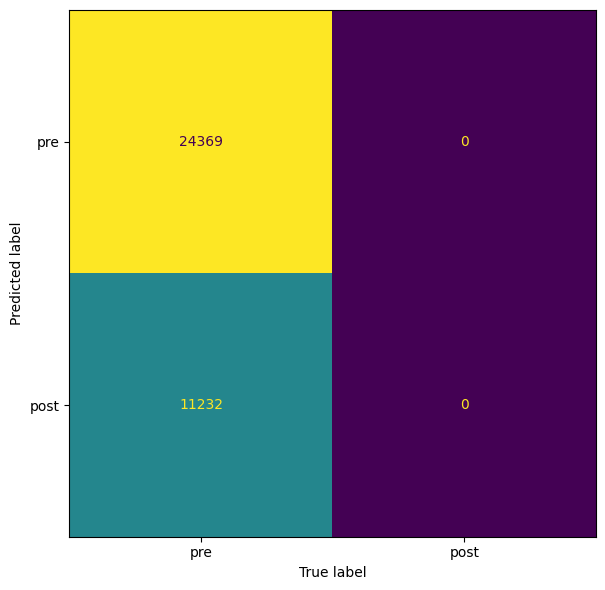

In [28]:
loader = FAS if Using == "CNN2D" else FAW
labels  = ["pre", "post"]
model.eval()

fig, ax = plt.subplots(figsize=(20, 6))

yt, yp = get_preds(model, loader)
cm = confusion_matrix(yt, yp, labels=[0, 1])
ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False)
ax.set_xlabel("True label")
ax.set_ylabel("Predicted label")


fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      1.000     0.685     0.813     35601
        post      0.000     0.000     0.000         0

    accuracy                          0.685     35601
   macro avg      0.500     0.342     0.406     35601
weighted avg      1.000     0.685     0.813     35601



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
mis_idx = np.where(yt != yp)[0]
test_events = Feb_Apr
eventi_test = [test_events[i][1] for i in range(len(test_events))]


tot_per_evento = Counter(eventi_test)
err_per_evento = Counter(test_events[i][1] for i in mis_idx)

df_err = pd.DataFrame({
    "evento": list(tot_per_evento.keys()),
    "Registrazioni Totali": [tot_per_evento[e] for e in tot_per_evento],
    "Registrazioni Errate": [err_per_evento.get(e, 0) for e in tot_per_evento]})

df_err["Percentuale Errata"] = (df_err["Registrazioni Errate"] / df_err["Registrazioni Totali"] * 100).round(2)

df_err = df_err[df_err["Registrazioni Errate"] > 0].reset_index(drop=True)
df_err = df_err.sort_values(["Percentuale Errata"], ascending = False).reset_index(drop=True)
df_err

,evento,registrazioni_totali,registrazioni_errate,Percentuale Errata
0,Event 7426,5,5,100.00
1,Event 7436,6,6,100.00
2,Event 10534,5,5,100.00
3,Event 10515,4,4,100.00
4,Event 7696,9,9,100.00
...,...,...,...,...
2706,Event 9102,20,1,5.00
2707,Event 8401,20,1,5.00
2708,Event 8865,20,1,5.00
2709,Event 8326,21,1,4.76


In [31]:
import plotly.express as px

# uso df_err che hai già: evento, registrazioni_totali, Registrazioni Errate, frazione_errata
df_plot = df_err.copy()
df_plot["time"] = df_plot["evento"].map(catalog["time"])

fig = px.scatter(
    df_plot, x="time", y="Percentuale Errata",
    size="Registrazioni Totali", color="Registrazioni Errate",
    hover_name="evento",
    hover_data=["Registrazioni Totali", "Registrazioni Errate", "Percentuale Errata"],
    color_continuous_scale="Reds",
)
fig.add_vline(x=pd.Timestamp("2016-04-21").timestamp()*1000,
              line_dash="dash", line_color="black")
fig.update_layout(width=1400, height=450, title=f"{Using}: errori per evento")
fig.show()